# Spectral Unmixing Demo Notebook
Follow installation instructions step in README.md prior to running this demo

In [1]:
using SpectralUnmixing
using Plots
using Statistics

# Library Preparation

Start by loading up a library, filtering it down to the desired classes, interpolating to the relevant wavelengths, and then removing undesired wavelength regions. By default the ignored regions correspond to atmospheric absorption regions. As the plots below show, all the endmember spectra within each class share general attributes while having small variations between them.

┌ Info: Ignoring wavelength regions: Any[[0, 440], [1310, 1490], [1770, 2050], [2440, 2880]]
└ @ SpectralUnmixing /Users/jhalani/Documents/EMIT-SDS/SpectralUnmixing/src/EndmemberLibrary.jl:110


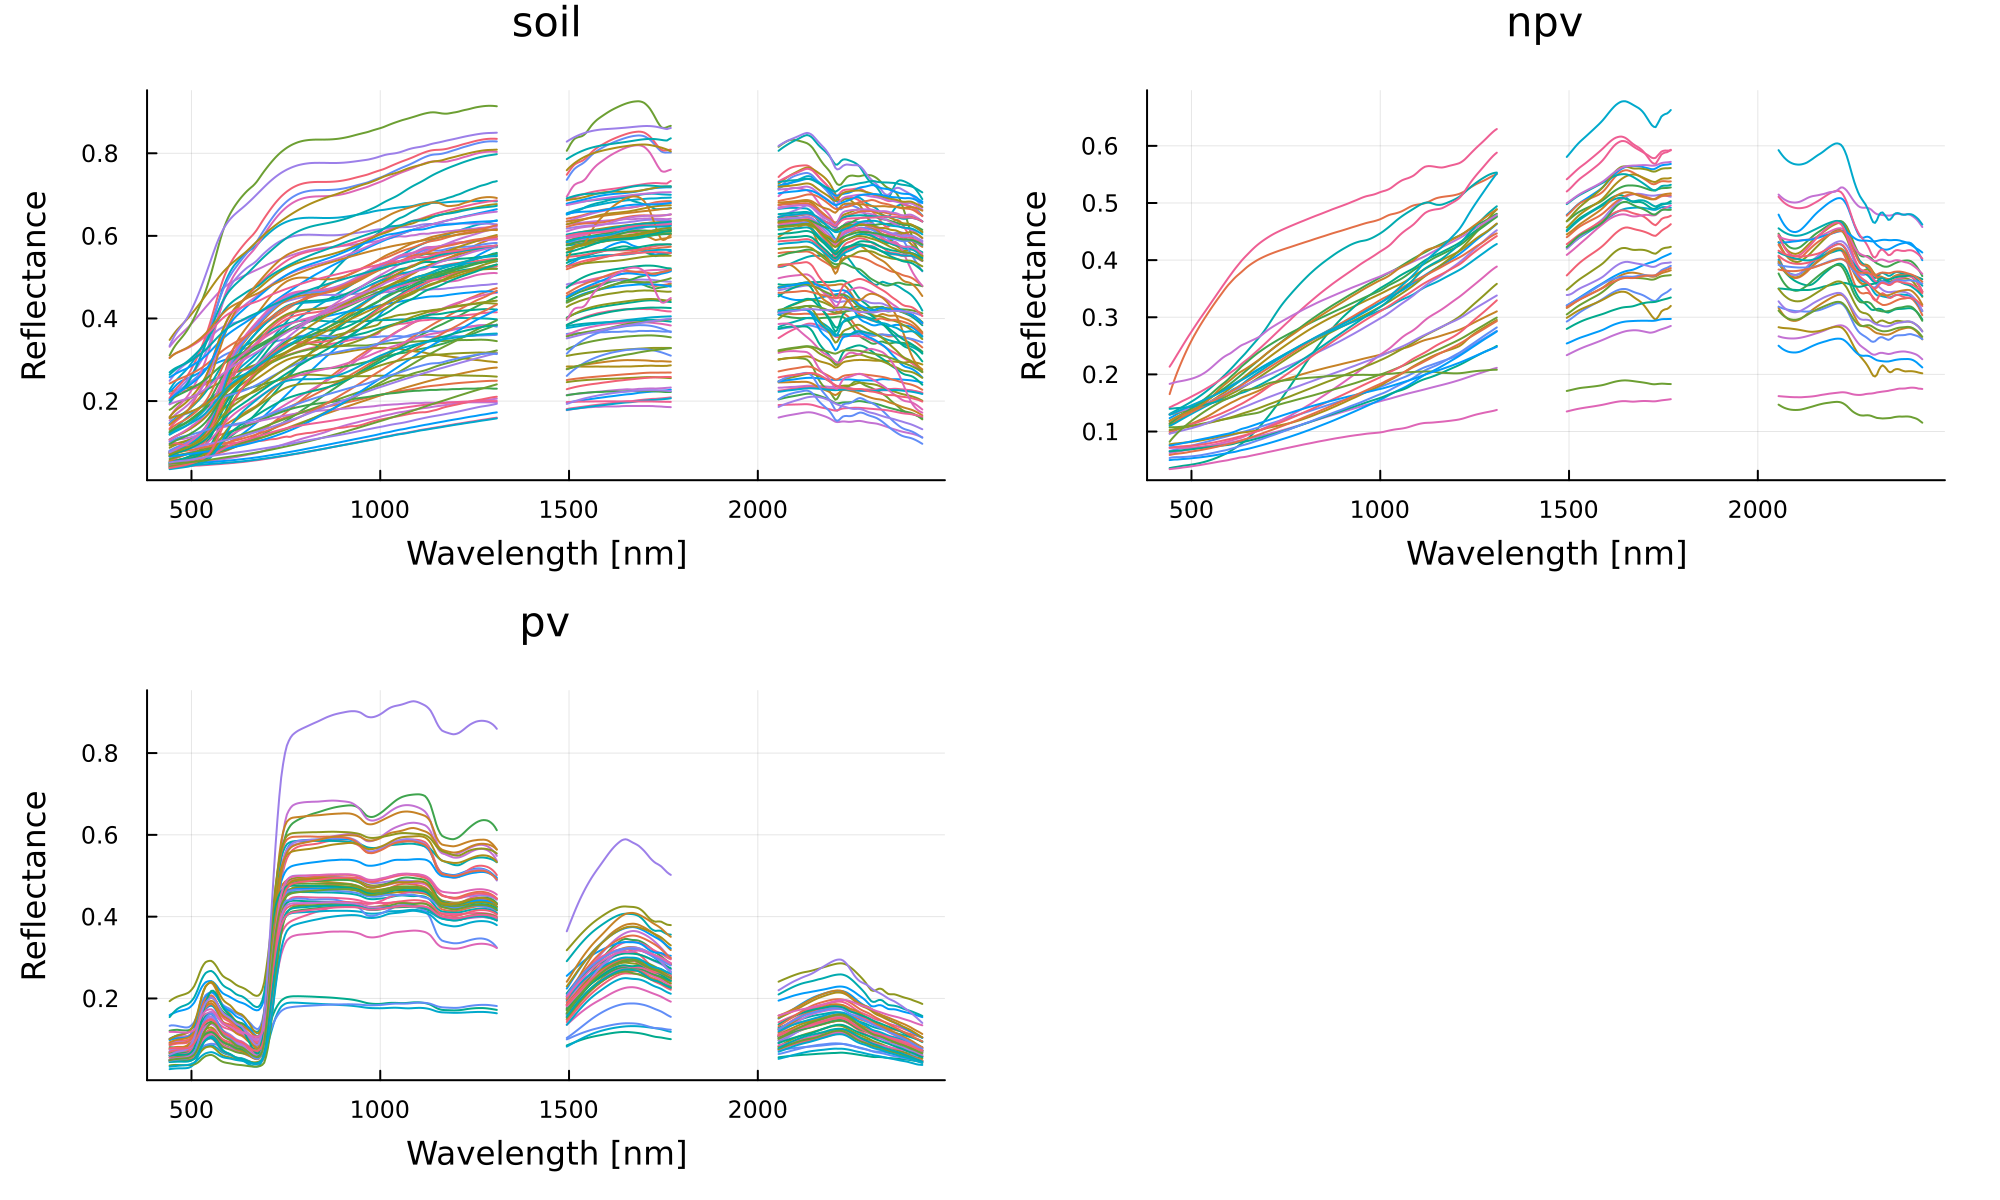

In [5]:
endmember_library = SpectralLibrary("convex_hull__n_dims_4_unmix_library.csv", "level_1", 8, 0, ["soil","npv","pv"]);
load_data!(endmember_library);
filter_by_class!(endmember_library);

refl_file_wl = read_envi_wavelengths("fake_refl");
interpolate_library_to_new_wavelengths!(endmember_library, refl_file_wl);

# fill the ignored regions with NaNs to improve visualization of the endmember spectra.
remove_wavelength_region_inplace!(endmember_library, true);

plot_endmembers_individually(endmember_library)
plot!(margin=5Plots.mm)


## Simulation and Unmixing Library Setup

Split the endmember library into training and testing sets using `split_library`. This function randomly allocates a fraction of endmembers from each class to one library and the remaining endmembers in another. Here we split the library in half using a fraction of `0.5`.

In [4]:
full_el = deepcopy(endmember_library)
# remove the ignored regions entirely instead of filling with NaNs to improve computational efficiency.
remove_wavelength_region_inplace!(full_el, false);

simulation_library, unmixing_library = split_library(full_el, 0.5);

# Simulate spectra

Now that we have a simulation and unmixing library, let's simulate a spectrum that we will subsequently retrieve

The `simulate_pixel` function is used below to create a simulated reflectance from 3 endmember components chosen evenly from each class from the simulation library. For this example we'll use the "class-even" combination type which ensures at least one endmember from each class is chosen.

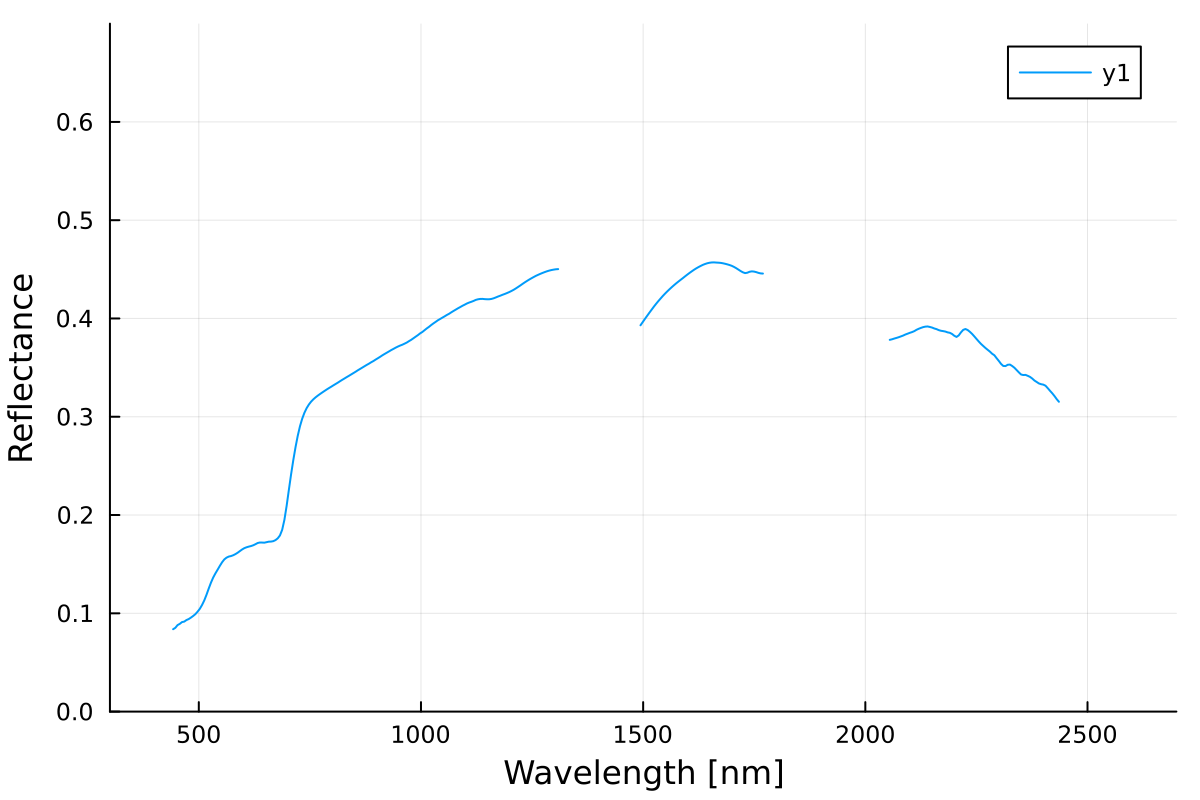

In [5]:
simulated_rfl, tcf, tmf = simulate_pixel(simulation_library, 3, "class-even", 13)
simulated_rfl = reshape(simulated_rfl, (1, size(simulated_rfl)[1]))

full_rfl = ones(size(endmember_library.wavelengths))
full_rfl[endmember_library.good_bands] = simulated_rfl[1,:]
plot(endmember_library.wavelengths, full_rfl, xlim=[300,2700])

xlabel!("Wavelength [nm]")
ylabel!("Reflectance")
xticks!([500, 1000, 1500, 2000, 2500])
ylims!(0,0.7)
plot!(dpi=200)
plot!()


# Run one case
Run one case to size up the outputs, and make sure things work.

In [6]:
#n_mc = 25
#mode = "sma"
#num_endmembers=[30]
#normalization="region-brightness"
#optimization="bvls"
#
#max_combinations=-1
#combination_type="class-even"


# MESMA
n_mc = 25
mode = "sma-best"
num_endmembers=[30]
normalization="brightness"
optimization="bvls"

max_combinations=100
combination_type="class-even"

class_idx = prepare_combinations(unmixing_library, combination_type)
options = prepare_options(unmixing_library, combination_type, num_endmembers, class_idx)


mr, mv, cfr, cfv = unmix_pixel(unmixing_library, simulated_rfl, nothing, class_idx, 									options, mode, n_mc,
            num_endmembers, normalization, optimization, max_combinations, combination_type);

Now that we know things work, run for some number of additiona instances, to build an output population.

In [7]:
num_instances = 100
mixture_results = zeros(num_instances, size(mr)[1])
comp_frac_results = zeros(num_instances, size(cfr)[1])
simulated_mixtures = zeros(num_instances, size(tmf)[1])

start_time = time()
for idx in 1:num_instances
    simulated_rfl, tcf, tmf = simulate_pixel(simulation_library, 3, "class-even", idx)
    simulated_rfl = reshape(simulated_rfl, (1, size(simulated_rfl)[1]))

    mr, mv, cfr, cfv = unmix_pixel(unmixing_library, simulated_rfl, nothing, class_idx,
    							   options, mode, n_mc, num_endmembers, normalization, 								   optimization, max_combinations, combination_type)

    mixture_results[idx,:] = mr
    comp_frac_results[idx,:] = cfr
    simulated_mixtures[idx,:] = tmf

end

println("Spectra per second: ", num_instances / (time() - start_time))

Spectra per second: 25.321352303692695


Now take a look at the performance.

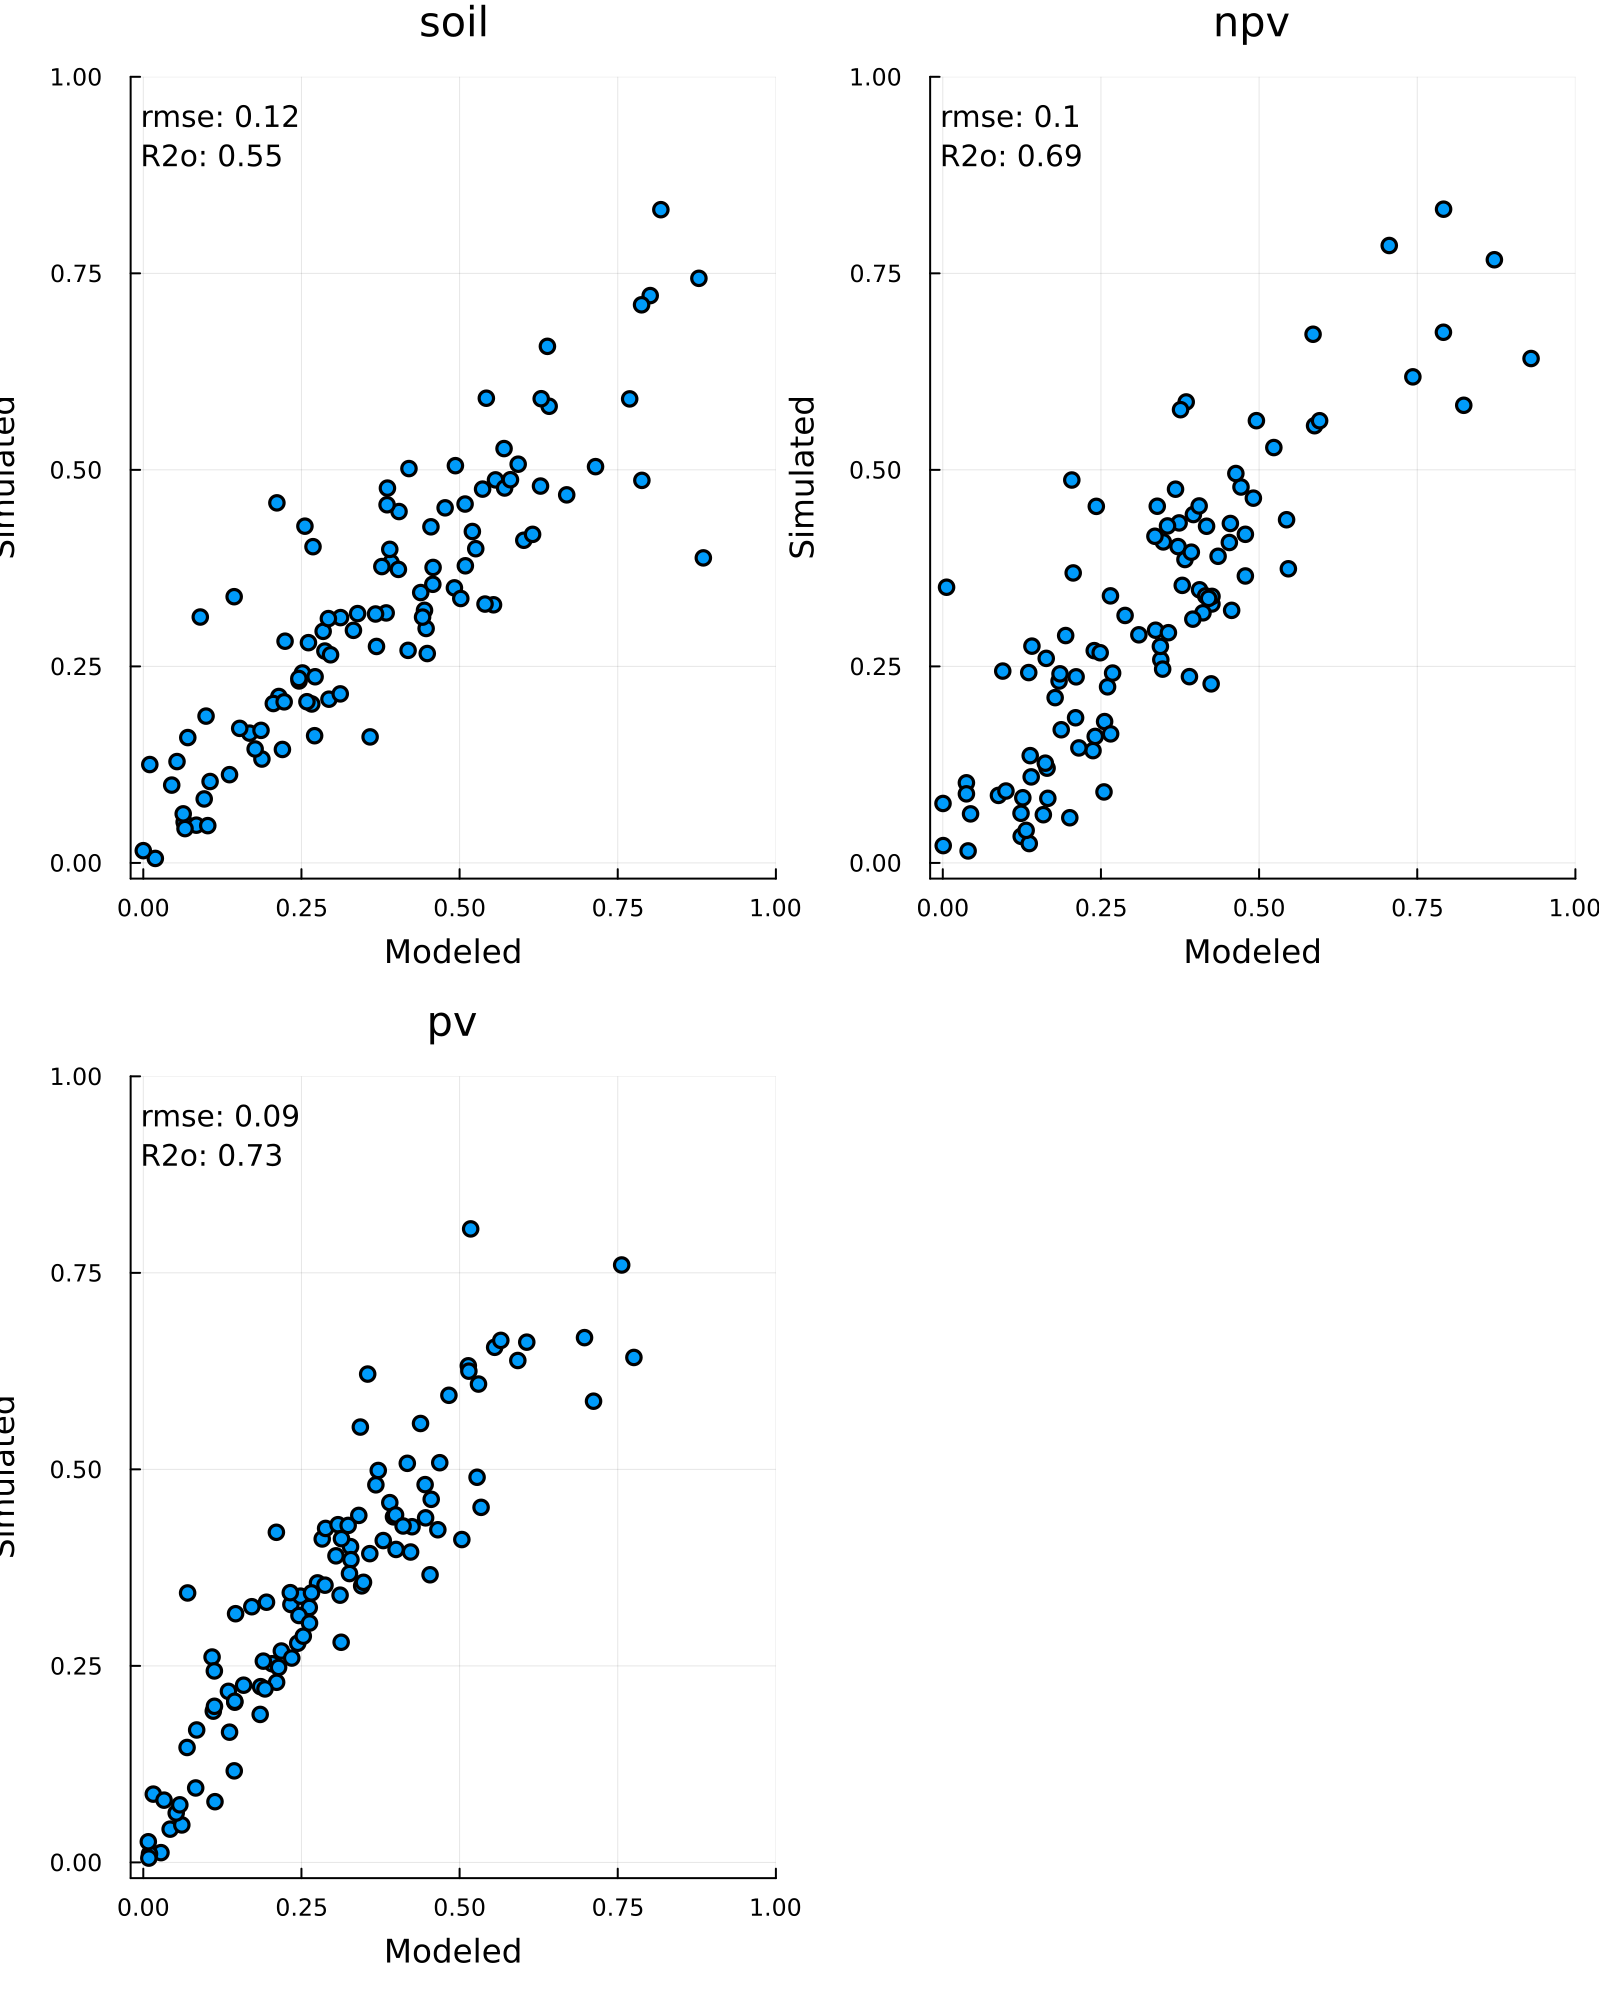

In [9]:
plots = []
for _u in 1:(size(mr)[1] - 1)
    p = plot(mixture_results[:,_u], simulated_mixtures[:,_u], seriestype = :scatter, title=unmixing_library.class_valid_keys[_u], xlabel="Modeled", ylabel="Simulated", legend=false)
    r2 = round(1 - sum( (simulated_mixtures[:,_u] - mixture_results[:,_u]).^2 ) /  sum( (simulated_mixtures[:,_u] .- mean(simulated_mixtures[:,_u])).^2 ),digits=2) # R2 around the 1-1 line, not against the linear trend line (bias sensitive)
    rmse = round(sqrt(mean((simulated_mixtures[:,_u] - mixture_results[:,_u]).^2)),digits=2)
    annotate!(0,0.9,text("R2o: " * string(r2),:left, 10))
    annotate!(0,0.95,text("rmse: " * string(rmse),:left, 10))
    xlims!(-0.02,1)
    ylims!(-0.02,1)
    push!(plots, p)
end
plot(plots...,size=(800,1000),dpi=200)